In [1]:
%run stochastic_lite.ipynb

In [2]:
####################
# Inputs
####################

sigma         = 1 # strain
NSegments     = 3
Fs            = 4096. # Hz
segmentDuration   = 64.0 # s
t0            = 0 # s
TAvg          = 4.0 # s

####################
# Computed quantities
####################

NSamplesPerSegment=segmentDuration*Fs 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
NAvgs = 2 * int(segmentDuration / TAvg) - 1

In [3]:
# generate data
data=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
times=np.arange(t0,t0+NSegments*segmentDuration,1/Fs)

ts=TimeSeries(times,data)

Text(0, 0.5, 'Strain')

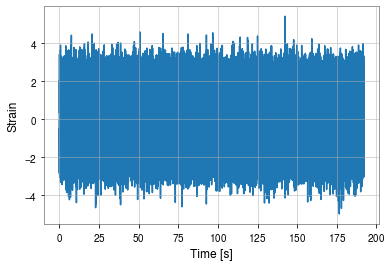

In [4]:
# plot time series
plt.plot(ts.times,ts.data)
plt.xlabel('Time [s]')
plt.ylabel('Strain')

Text(0, 0.5, 'Strain')

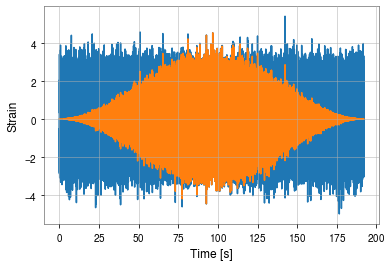

In [5]:
#plt windowed data
ts_w=ts.window()
plt.plot(ts.times,ts.data)
plt.plot(ts_w.times,ts_w.data)
plt.xlabel('Time [s]')
plt.ylabel('Strain')

Text(0, 0.5, 'Strain')

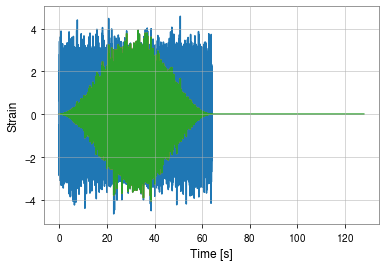

In [6]:
# slice time series data, then window and zero-pad
d1_left=slice_time_series(ts,0,int(segmentDuration/ts.deltaT))
plt.plot(d1_left.times,d1_left.data)
d1_left_w=d1_left.window()
plt.plot(d1_left_w.times,d1_left_w.data)
d1_left_wz=d1_left_w.zero_pad()
plt.plot(d1_left_wz.times,d1_left_wz.data)
plt.xlabel('Time [s]')
plt.ylabel('Strain')

Text(0, 0.5, 'Fourier transform')

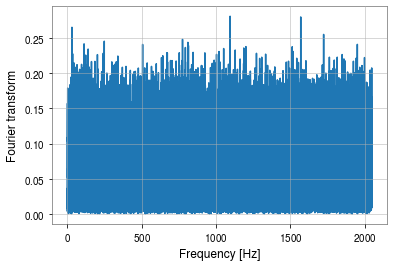

In [7]:
# fft data and plot frequency series
d1_left=slice_time_series(ts,0,int(segmentDuration/ts.deltaT))
d1_left_tilde=d1_left.window_and_fft()
plt.plot(d1_left_tilde.freqs,np.abs(d1_left_tilde.data))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Fourier transform')

Text(0, 0.5, 'Fourier transform')

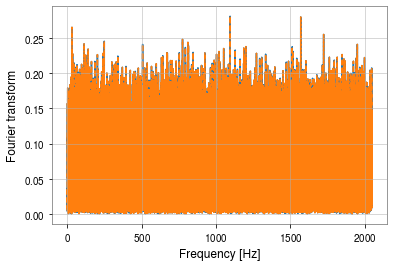

In [8]:
# test multiply and divide frequency series
x=d1_left_tilde/d1_left_tilde * d1_left_tilde
plt.plot(x.freqs,np.abs(x.data))
plt.plot(d1_left_tilde.freqs,np.abs(d1_left_tilde.data),linestyle='--')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Fourier transform')

0.0
0.25
2047.75


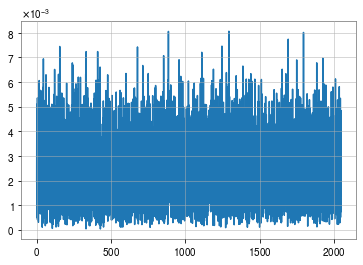

In [9]:
# test coarse-graining
d1_left_tilde_cg=d1_left_tilde.coarse_grain(0.25)
plt.plot(d1_left_tilde_cg.freqs,np.abs(d1_left_tilde_cg.data))

print(d1_left_tilde_cg.freqs[0])
print(d1_left_tilde_cg.freqs[1]-d1_left_tilde_cg.freqs[0])
print(d1_left_tilde_cg.freqs[-1])

(0, 50)

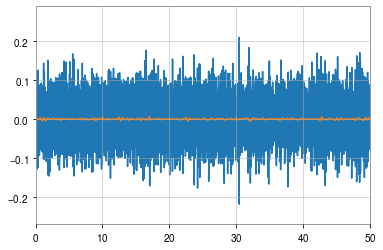

In [10]:
# compare frequency data before and after coarse graining
plt.plot(d1_left_tilde.freqs,np.imag(d1_left_tilde.data))
plt.plot(d1_left_tilde_cg.freqs,np.imag(d1_left_tilde_cg.data))
plt.xlim(0,50)

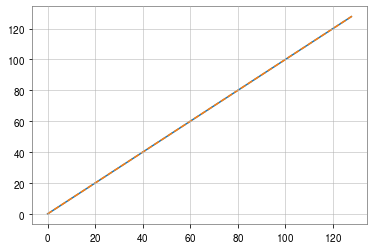

In [11]:
# test coarse graining on linear function of frequency
freqs=np.arange(0,128,0.03125)
testFS=FrequencySeries(freqs,freqs)
testFS_cg=testFS.coarse_grain(0.25)
plt.plot(testFS_cg.freqs,np.abs(testFS_cg.data))
plt.plot(testFS.freqs,np.abs(testFS.data),linestyle='--')